In [1]:
import os
import json
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize 

In [2]:
df= pd.read_csv('/Users/pranesh/coding2/MachineLearningFrom0/datasets/spotify_millsongdata.csv')

In [3]:
df.head(100)

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...
...,...,...,...,...
95,ABBA,The Name Of The Game,/a/abba/the+name+of+the+game_20002863.html,"I've seen you twice, in a short time \r\nOnly..."
96,ABBA,The Piper,/a/abba/the+piper_20002946.html,They came from the hills \r\nAnd they came fr...
97,ABBA,The Visitors,/a/abba/the+visitors_20002864.html,I hear the doorbell ring and suddenly the pani...
98,ABBA,The Way Old Friends Do,/a/abba/the+way+old+friends+do_20002573.html,You and I can share the silence \r\nFinding c...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57650 entries, 0 to 57649
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   artist  57650 non-null  object
 1   song    57650 non-null  object
 2   link    57650 non-null  object
 3   text    57650 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [5]:
df.isnull().sum()

artist    0
song      0
link      0
text      0
dtype: int64

In [6]:
top_artists = df['artist'].value_counts().head(10)
print(top_artists)

artist
Donna Summer        191
Gordon Lightfoot    189
Bob Dylan           188
George Strait       188
Loretta Lynn        187
Cher                187
Alabama             187
Reba Mcentire       187
Chaka Khan          186
Dean Martin         186
Name: count, dtype: int64


In [7]:
df = df.sample(10000)

In [8]:
df = df.drop('link', axis = 1).reset_index(drop = True)

In [9]:
df

,artist,song,text
0,Who,I Don't Even Know Myself,There's nothing in the way I walk that could t...
1,Styx,Witch Wolf,Reoccurring symptoms \r\nAnswer the baleful h...
2,Underworld,Show Some Emotion,Wait you've gone too far \r\nWho for God's sa...
3,Cher,Good Combination,Baby don't you worry \r\nWhen things ain't go...
4,Grand Funk Railroad,Please Me,"Five million guys have tried to reduce her, \..."
...,...,...,...
9995,Pharrell Williams,Here,My dear it seems we're here again \r\nSo much...
9996,Point Of Grace,All I'll Ever Need,Some days I'm fragile \r\nSome days I'm stron...
9997,Backstreet Boys,Bye Bye Love,"Yeah, yeah, oh, \r\nYeah, yeah, \r\n \r\nYo..."
9998,Kid Rock,Step In Stride,I think you might like to hear something from ...


In [10]:
all_lyrics = " ".join(df['text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_lyrics)

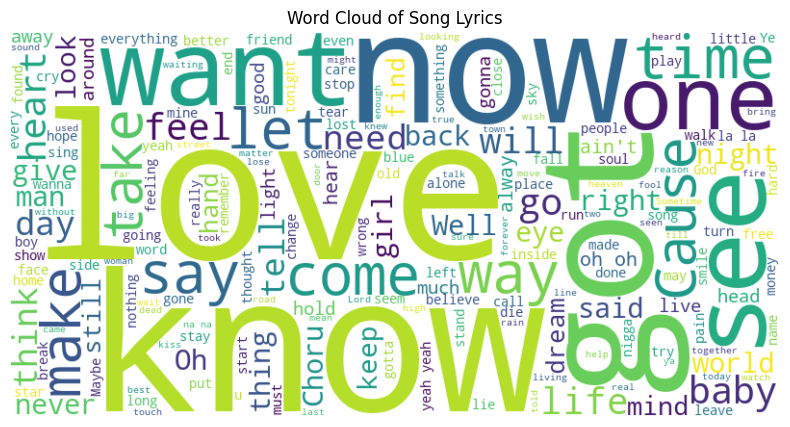

In [12]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Song Lyrics')
plt.show()


In [13]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /Users/pranesh/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pranesh/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/pranesh/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [14]:
stop_words = set(stopwords.words('english'))

In [15]:
def preprocess_text(text):
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

In [16]:
df['cleaned_text'] = df['text'].apply(preprocess_text)


In [ ]:
tfidf_vectorizer = 